In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Ready for Project 3!")

Ready for Project 3!


In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 500

df = pd.DataFrame({
    'CustomerID': range(1, n+1),
    'Name': ['John', 'jane', 'MIKE', 'sarah', 'TOM'] * 100,
    'Age': np.random.randint(18, 70, n),
    'Email': ['john@gmail.com', 'JANE@gmail.com',
              'mike@gmail.com', None, 'tom@gmail.com'] * 100,
    'Phone': ['9876543210', '123-456-7890',
              None, '9876543210', '555.555.5555'] * 100,
    'Purchase_Amount': np.random.randint(100, 10000, n),
    'Date': ['2023-01-01', '01/02/2023',
             '2023-03-01', None, '2023-04-01'] * 100,
    'City': ['Chennai', 'chennai', 'CHENNAI',
             'Mumbai', None] * 100,
})

# Add duplicates
df = pd.concat([df, df.sample(50)], ignore_index=True)

# Add outliers
df.loc[0, 'Purchase_Amount'] = 999999
df.loc[1, 'Purchase_Amount'] = -500

df.to_csv('messy_data.csv', index=False)
print("Messy dataset created!")
print("Shape:", df.shape)
print(df.head(10))

Messy dataset created!
Shape: (550, 8)
   CustomerID   Name  Age           Email         Phone  Purchase_Amount  \
0           1   John   56  john@gmail.com    9876543210           999999   
1           2   jane   69  JANE@gmail.com  123-456-7890             -500   
2           3   MIKE   46  mike@gmail.com           NaN             9762   
3           4  sarah   32             NaN    9876543210              680   
4           5    TOM   60   tom@gmail.com  555.555.5555             7104   
5           6   John   25  john@gmail.com    9876543210             8230   
6           7   jane   38  JANE@gmail.com  123-456-7890             3247   
7           8   MIKE   56  mike@gmail.com           NaN             4349   
8           9  sarah   36             NaN    9876543210             1779   
9          10    TOM   40   tom@gmail.com  555.555.5555             3606   

         Date     City  
0  2023-01-01  Chennai  
1  01/02/2023  chennai  
2  2023-03-01  CHENNAI  
3         NaN   Mumbai  

In [3]:
df = pd.read_csv('messy_data.csv')

print("=== DATASET INFO ===")
print("Shape:", df.shape)
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())
print("\n=== DUPLICATES ===")
print("Duplicate rows:", df.duplicated().sum())
print("\n=== DATA TYPES ===")
print(df.dtypes)
print("\n=== SAMPLE DATA ===")
print(df.head())

=== DATASET INFO ===
Shape: (550, 8)

=== MISSING VALUES ===
CustomerID           0
Name                 0
Age                  0
Email              109
Phone              111
Purchase_Amount      0
Date               109
City               110
dtype: int64

=== DUPLICATES ===
Duplicate rows: 50

=== DATA TYPES ===
CustomerID         int64
Name                 str
Age                int64
Email                str
Phone                str
Purchase_Amount    int64
Date                 str
City                 str
dtype: object

=== SAMPLE DATA ===
   CustomerID   Name  Age           Email         Phone  Purchase_Amount  \
0           1   John   56  john@gmail.com    9876543210           999999   
1           2   jane   69  JANE@gmail.com  123-456-7890             -500   
2           3   MIKE   46  mike@gmail.com           NaN             9762   
3           4  sarah   32             NaN    9876543210              680   
4           5    TOM   60   tom@gmail.com  555.555.5555             

In [4]:
print("Before cleaning:", df.shape)

# Fill missing email with unknown
df['Email'].fillna('unknown@email.com', inplace=True)

# Fill missing phone with unknown
df['Phone'].fillna('0000000000', inplace=True)

# Fill missing date with most common date
df['Date'].fillna(df['Date'].mode()[0], inplace=True)

# Fill missing city with most common city
df['City'].fillna(df['City'].mode()[0], inplace=True)

print("Missing values after fix:")
print(df.isnull().sum())

Before cleaning: (550, 8)
Missing values after fix:
CustomerID           0
Name                 0
Age                  0
Email              109
Phone              111
Purchase_Amount      0
Date               109
City               110
dtype: int64


In [5]:
print("Before removing duplicates:", df.shape)
df.drop_duplicates(inplace=True)
print("After removing duplicates:", df.shape)
print("Removed:", 550 - len(df), "duplicate rows")

Before removing duplicates: (550, 8)
After removing duplicates: (500, 8)
Removed: 50 duplicate rows


In [6]:
# Fix name formatting
df['Name'] = df['Name'].str.strip().str.title()

# Fix email formatting
df['Email'] = df['Email'].str.strip().str.lower()

# Fix city formatting
df['City'] = df['City'].str.strip().str.title()

print("=== AFTER TEXT STANDARDIZATION ===")
print(df[['Name', 'Email', 'City']].head(10))

=== AFTER TEXT STANDARDIZATION ===
    Name           Email     City
0   John  john@gmail.com  Chennai
1   Jane  jane@gmail.com  Chennai
2   Mike  mike@gmail.com  Chennai
3  Sarah             NaN   Mumbai
4    Tom   tom@gmail.com      NaN
5   John  john@gmail.com  Chennai
6   Jane  jane@gmail.com  Chennai
7   Mike  mike@gmail.com  Chennai
8  Sarah             NaN   Mumbai
9    Tom   tom@gmail.com      NaN


In [7]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Date'].fillna(df['Date'].mode()[0], inplace=True)

print("Date column fixed!")
print(df['Date'].dtype)
print(df['Date'].head())

Date column fixed!
datetime64[us]
0   2023-01-01
1          NaT
2   2023-03-01
3          NaT
4   2023-04-01
Name: Date, dtype: datetime64[us]


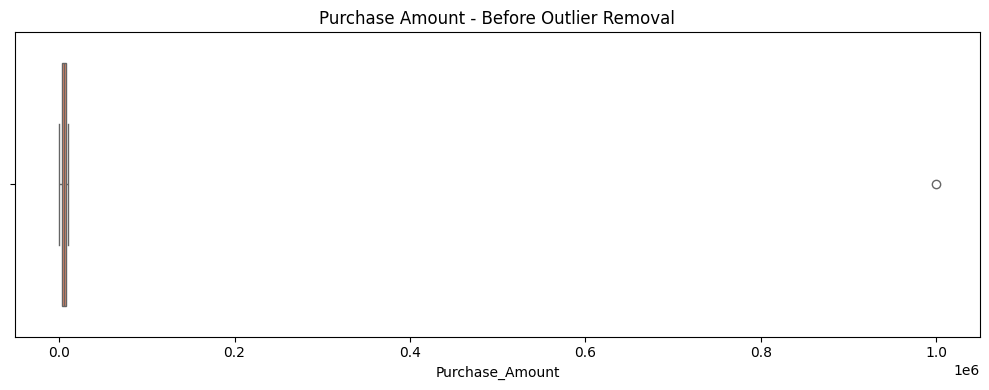

Removed 1 outliers


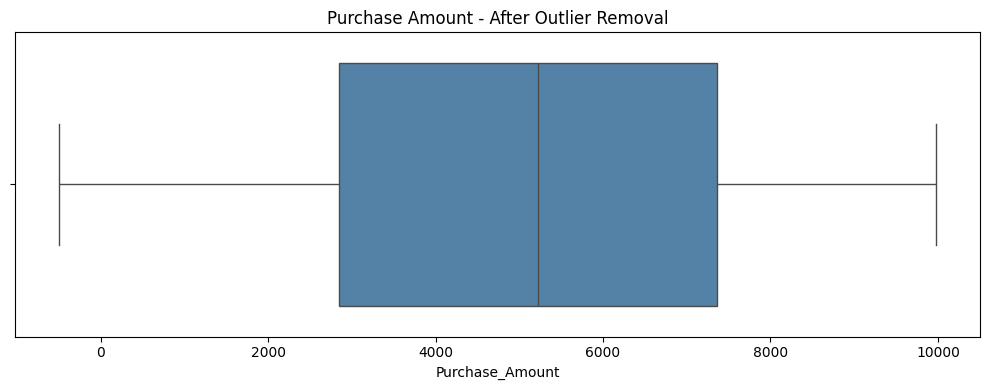

Charts saved!


In [8]:
# Show outliers before
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Purchase_Amount'], color='coral')
plt.title('Purchase Amount - Before Outlier Removal')
plt.tight_layout()
plt.savefig('before_outliers.png')
plt.show()

# Remove outliers using IQR
Q1 = df['Purchase_Amount'].quantile(0.25)
Q3 = df['Purchase_Amount'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

before = len(df)
df = df[(df['Purchase_Amount'] >= lower) &
        (df['Purchase_Amount'] <= upper)]
print(f"Removed {before - len(df)} outliers")

# Show after
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['Purchase_Amount'], color='steelblue')
plt.title('Purchase Amount - After Outlier Removal')
plt.tight_layout()
plt.savefig('after_outliers.png')
plt.show()
print("Charts saved!")

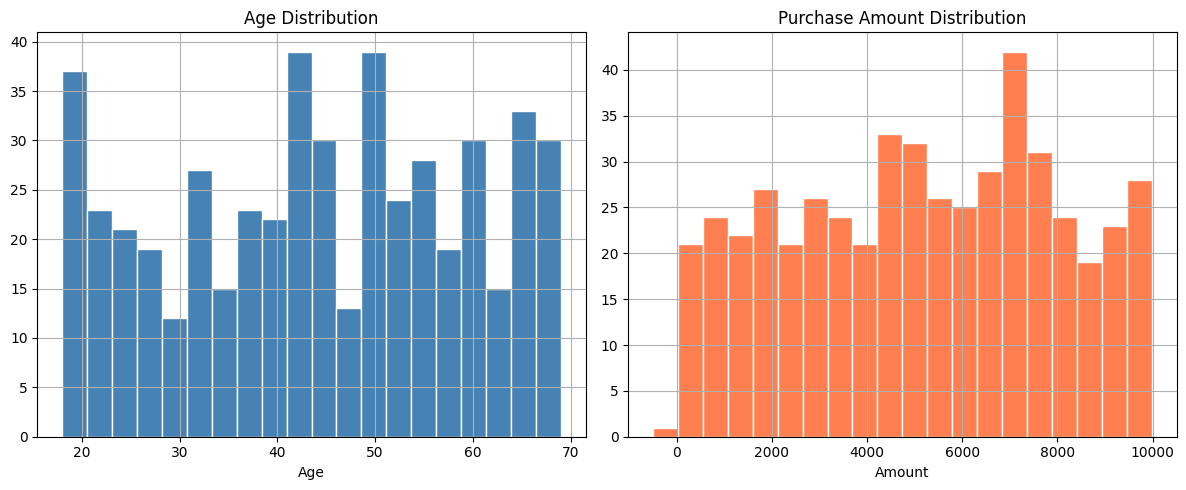

Chart saved!


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Age distribution
df['Age'].hist(bins=20, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')

# Purchase amount distribution
df['Purchase_Amount'].hist(bins=20, ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Purchase Amount Distribution')
axes[1].set_xlabel('Amount')

plt.tight_layout()
plt.savefig('distributions.png')
plt.show()
print("Chart saved!")

In [10]:
df.to_csv('cleaned_data.csv', index=False)
print("Clean data saved!")

Clean data saved!
